In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ruptures as rpt
import seaborn as sns

In [2]:
health_df = pd.read_csv("../data/dataset.csv")

In [3]:
health_df.head()

,type,sourceName,unit,creationDate,startDate,endDate,value
0,HKQuantityTypeIdentifierActiveEnergyBurned,Apple Watch,kcal,2022-01-01 00:00:03 +0900,2021-12-31 23:53:45 +0900,2021-12-31 23:54:46 +0900,0.172
1,HKQuantityTypeIdentifierActiveEnergyBurned,Apple Watch,kcal,2022-01-01 00:00:03 +0900,2021-12-31 23:54:57 +0900,2021-12-31 23:55:48 +0900,0.239
2,HKQuantityTypeIdentifierActiveEnergyBurned,Apple Watch,kcal,2022-01-01 00:00:03 +0900,2021-12-31 23:55:58 +0900,2021-12-31 23:57:00 +0900,0.188
3,HKQuantityTypeIdentifierActiveEnergyBurned,Apple Watch,kcal,2022-01-01 00:00:03 +0900,2021-12-31 23:57:00 +0900,2021-12-31 23:57:10 +0900,0.067
4,HKQuantityTypeIdentifierHeartRate,Apple Watch,count/min,2022-01-01 00:00:03 +0900,2021-12-31 23:57:35 +0900,2021-12-31 23:57:35 +0900,79


In [4]:
omron_df = health_df[health_df["sourceName"] == "omron connect"]

In [5]:
# 体重
weight_df = omron_df[omron_df["type"] == "HKQuantityTypeIdentifierBodyMass"].reset_index(drop=True)
weight_df["value"] = weight_df["value"].astype(float)
weight_df["date"] = pd.to_datetime(weight_df["creationDate"])
weight_df = weight_df[["date", "value"]]
weight_df = weight_df.set_index("date")
weight_df = weight_df.rename(columns={"value": "weight"})

# 月ごとの平均体重を算出
weight_df = weight_df.resample("M").mean().reset_index()


/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_48351/1992722748.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weight_df = weight_df.resample("M").mean().reset_index()


In [6]:
# 体脂肪率
fat_ratio_df = omron_df[omron_df["type"] == "HKQuantityTypeIdentifierBodyFatPercentage"].reset_index(drop=True)
fat_ratio_df["value"] = fat_ratio_df["value"].astype(float)

# 体脂肪率をパーセント表記に変換
fat_ratio_df["value"] = fat_ratio_df["value"] * 100
fat_ratio_df["date"] = pd.to_datetime(fat_ratio_df["creationDate"])
fat_ratio_df = fat_ratio_df[["date", "value"]]
fat_ratio_df = fat_ratio_df.set_index("date")
fat_ratio_df = fat_ratio_df.rename(columns={"value": "fat_ratio"})

# 月ごとの平均体脂肪率を算出
fat_ratio_df = fat_ratio_df.resample("M").mean().reset_index()


/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_48351/3067408446.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fat_ratio_df = fat_ratio_df.resample("M").mean().reset_index()


In [7]:
# 運動量
exercise_df = health_df[health_df["type"] == "HKQuantityTypeIdentifierAppleExerciseTime"]
exercise_df["value"] = exercise_df["value"].astype(float)
exercise_df["date"] = pd.to_datetime(exercise_df["creationDate"])
exercise_df = exercise_df[["date", "value"]]
exercise_df = exercise_df.set_index("date")
exercise_df = exercise_df.rename(columns={"value": "exercise_time"})

# 月ごとの運動量合計を算出
exercise_df = exercise_df.resample("M").sum().reset_index()

/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_48351/3298346864.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exercise_df["value"] = exercise_df["value"].astype(float)
/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_48351/3298346864.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  exercise_df["date"] = pd.to_datetime(exercise_df["creationDate"])
/var/folders/4z/1p_57nbd6cs865rxxqy027kc0000gq/T/ipykernel_48351/3298346864.py:10: FutureWarning: 'M' is deprecated and will be remo

In [8]:
# 体重計に乗っていない月があるので、オムロン経由データは少ない
print(weight_df.shape, fat_ratio_df.shape, exercise_df.shape)

(30, 2) (30, 2) (32, 2)


In [9]:
merged_df = pd.merge(weight_df, fat_ratio_df, on="date", how="inner")
merged_df = pd.merge(merged_df, exercise_df, on="date", how="inner")

In [10]:
merged_df

,date,weight,fat_ratio,exercise_time
0,2022-01-31 00:00:00+09:00,60.952941,17.476471,370.0
1,2022-02-28 00:00:00+09:00,60.097500,16.720000,553.0
2,2022-03-31 00:00:00+09:00,59.261111,16.307407,311.0
3,2022-04-30 00:00:00+09:00,59.453125,16.562500,610.0
4,2022-05-31 00:00:00+09:00,59.973333,17.326667,876.0
5,2022-06-30 00:00:00+09:00,60.295455,17.322727,846.0
6,2022-07-31 00:00:00+09:00,60.417857,17.357143,900.0
7,2022-08-31 00:00:00+09:00,60.132609,16.534783,741.0
8,2022-09-30 00:00:00+09:00,60.006250,16.337500,609.0
9,2022-10-31 00:00:00+09:00,59.557692,16.492308,830.0


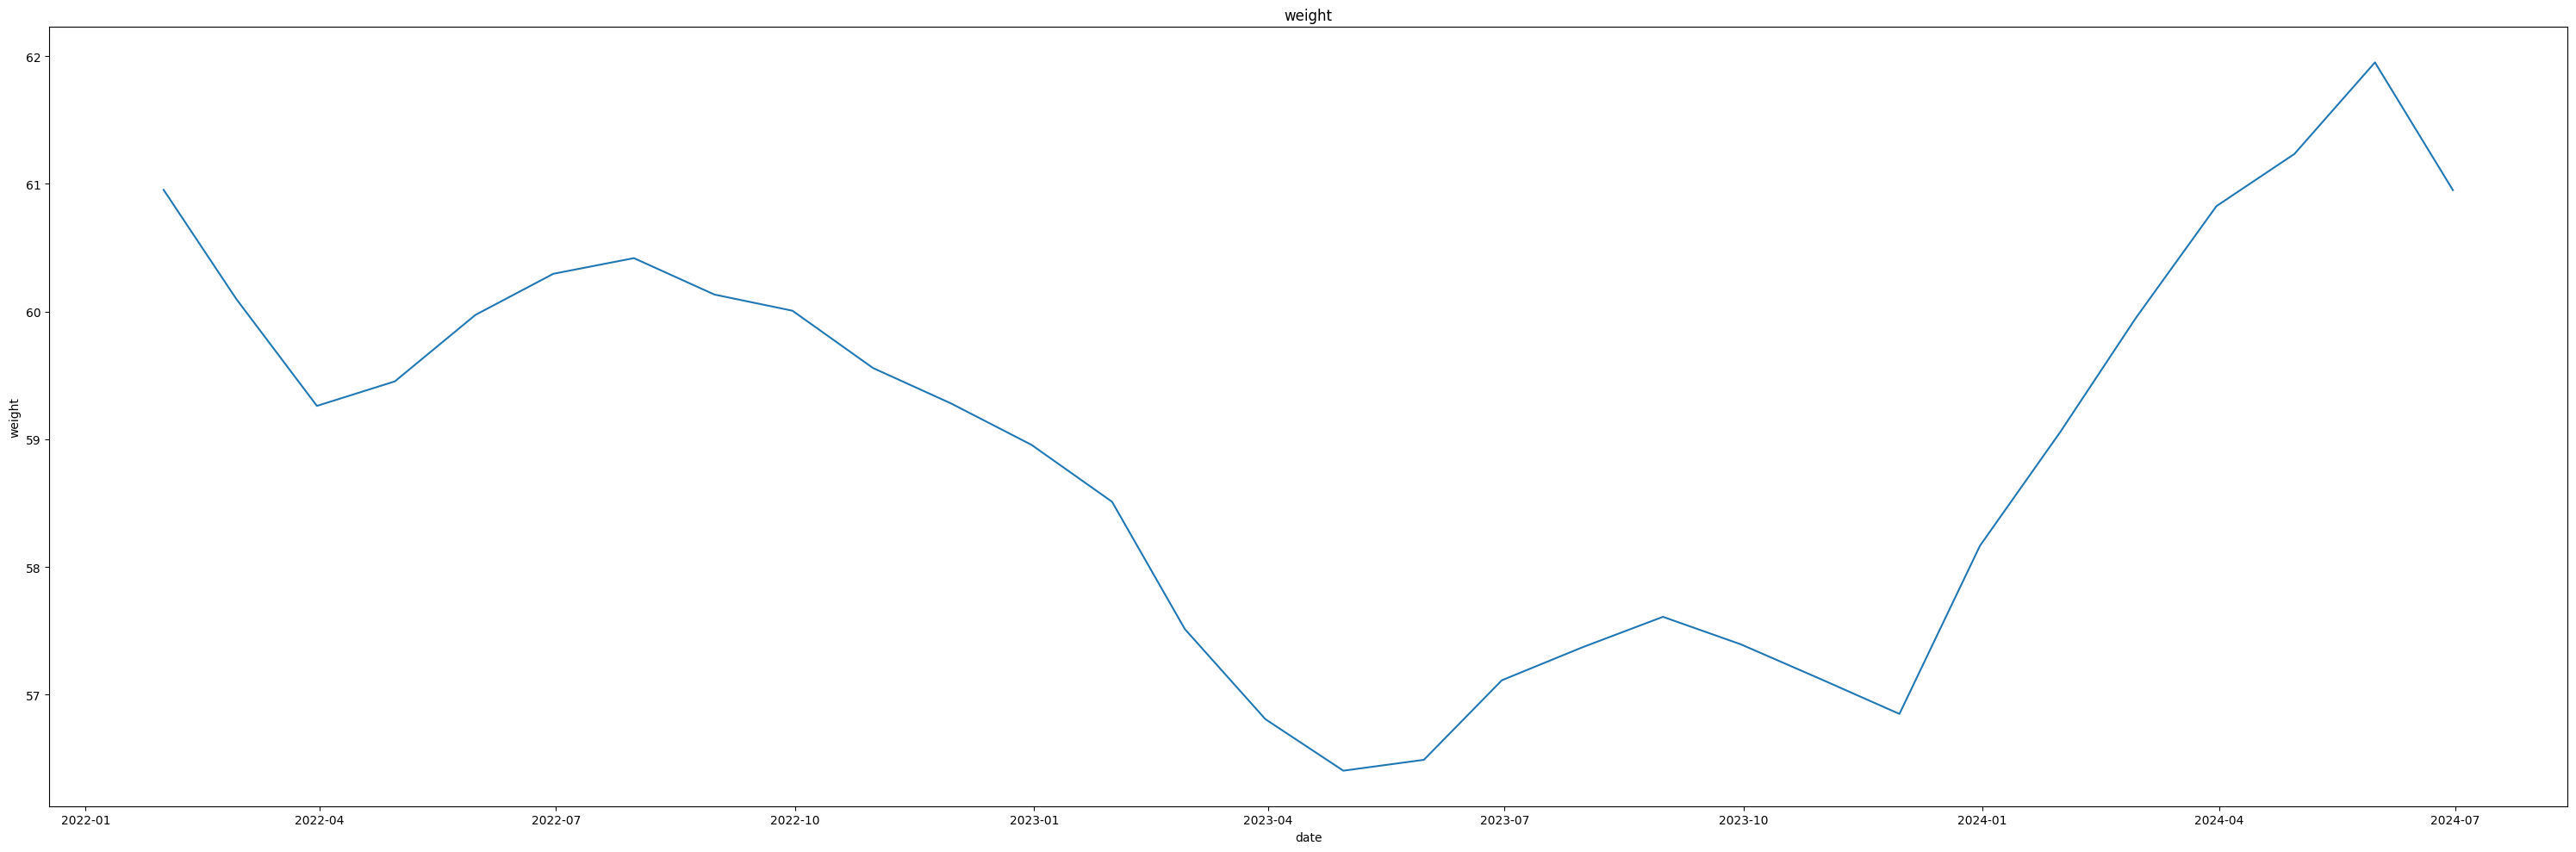

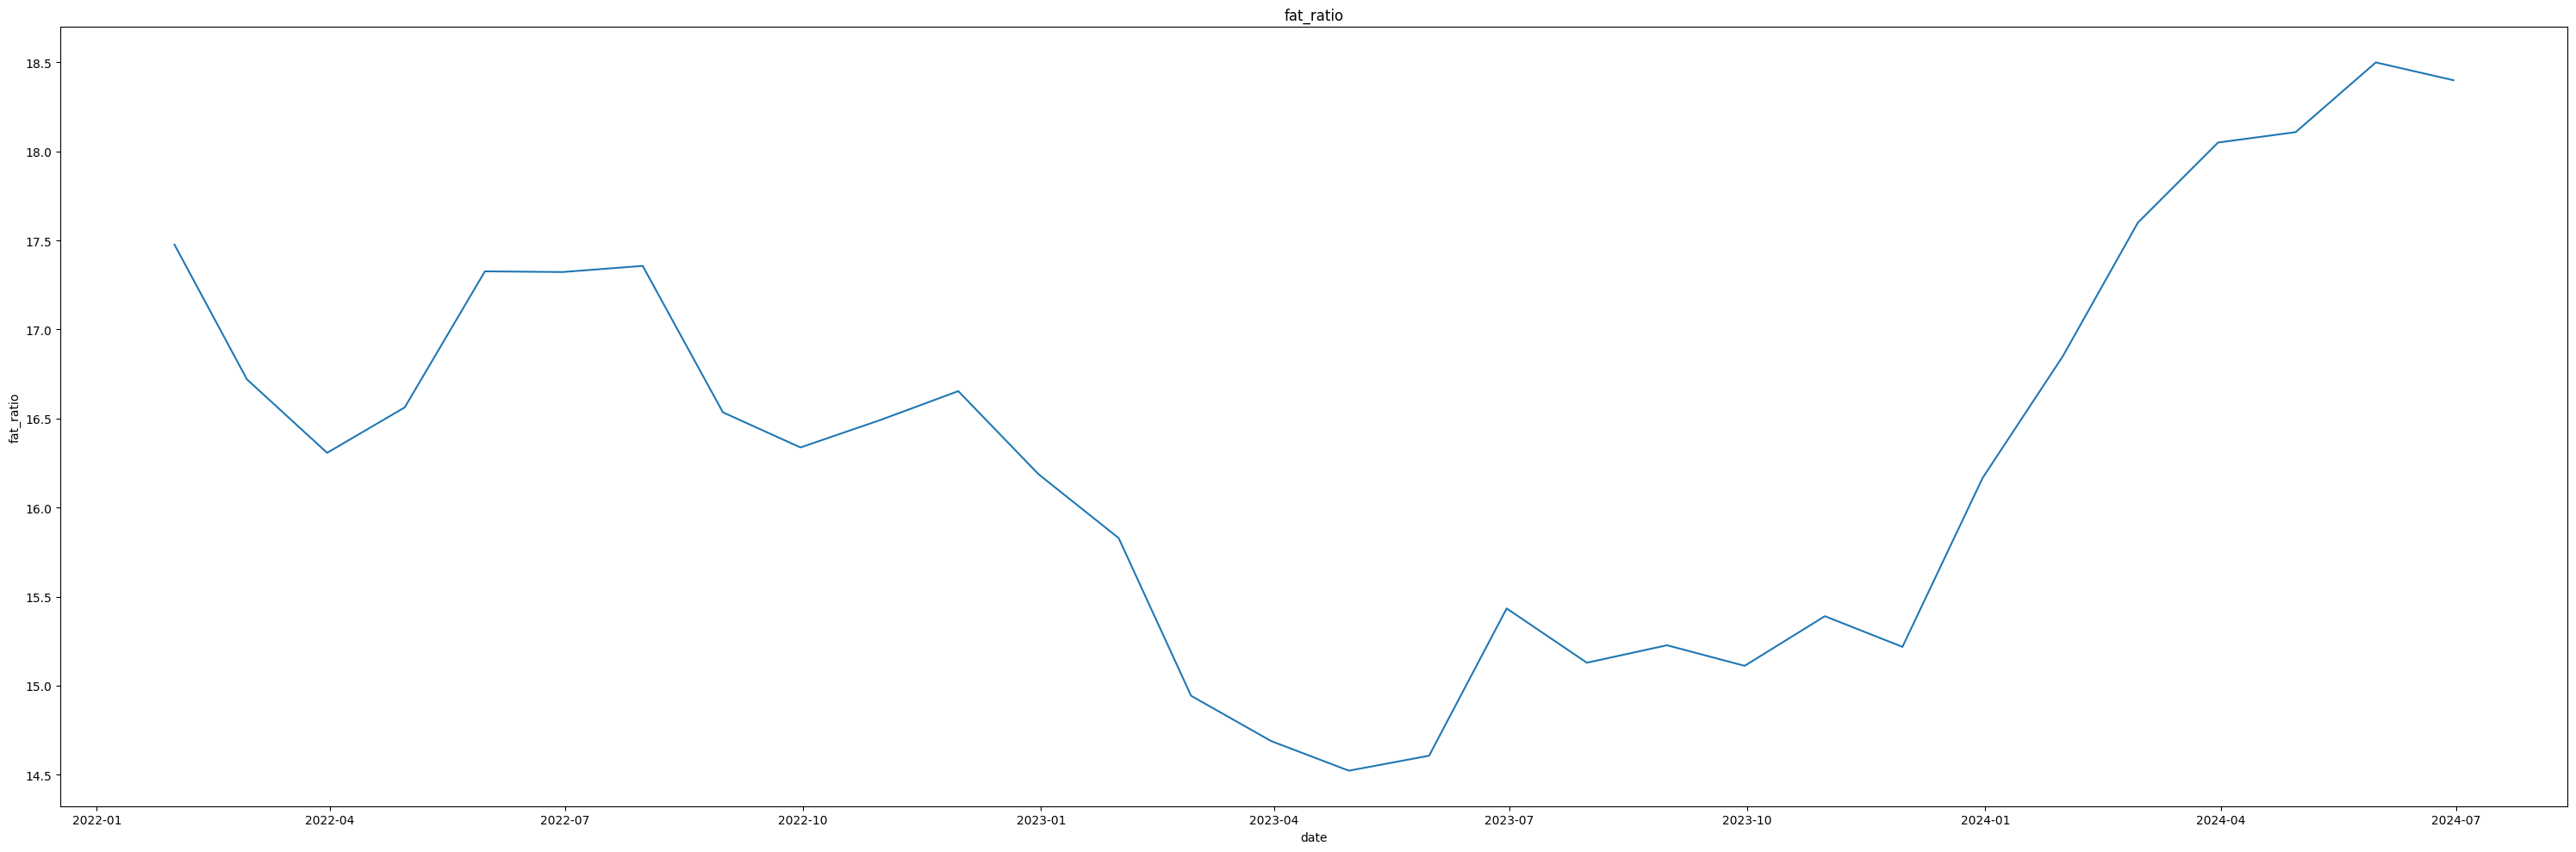

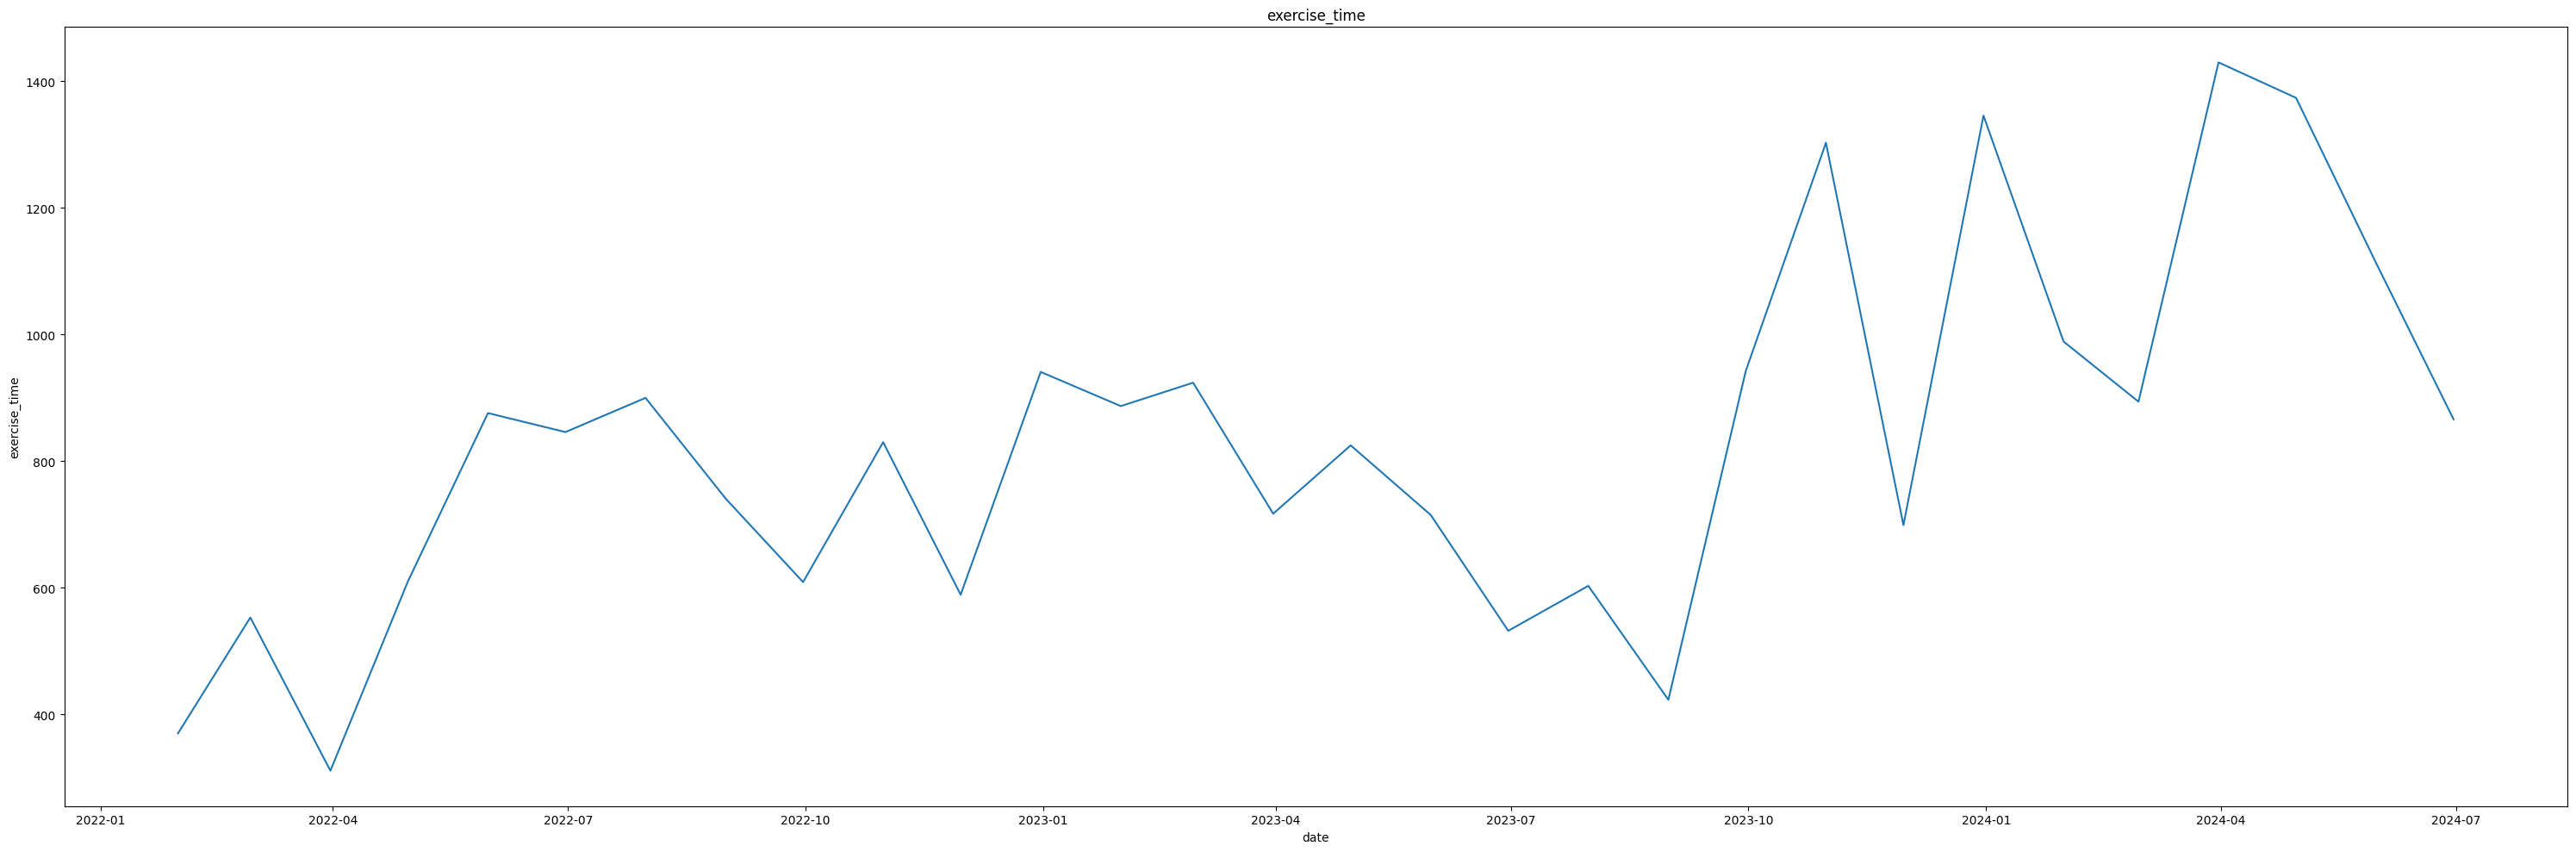

In [11]:
target_col = ["weight", "fat_ratio", "exercise_time"]

for col in target_col:
    plt.figure(figsize=(30, 10))
    sns.lineplot(data=merged_df, x="date", y=col)
    plt.title(col)
    plt.tight_layout()
    plt.show()

### 変化点を推定
- Ref: https://centre-borelli.github.io/ruptures-docs/

In [12]:
def predict_change_points(data: np.ndarray, model: str = "l2", n_bkps: int = 4) -> list[int]:
    # アルゴリズム設定と学習
    algo = rpt.Dynp(model=model).fit(data)

    # 変化点の推定
    return algo.predict(n_bkps=n_bkps)


def plot_chage_points(
    result: list[int],
    data: np.ndarray,
    x_labels: np.ndarray,
    target_col: list,
    marker: str = None,
) -> None:
    # 変化点の可視化
    change_points = [x_labels[i - 1] for i in result]

    for i in range(data.shape[1]):
        plt.figure(figsize=(12, 6))
        plt.plot(x_labels, data[:, i], marker=marker)

        # 変化点の日付のみをx軸に表示
        plt.xticks(change_points, rotation=90)

        for cp in change_points:
            plt.axvline(x=cp, color="r", linestyle="--", label="Change Point" if cp == change_points[0] else "")

        plt.xlabel("Change Points")
        plt.ylabel("Value")
        plt.title(target_col[i])
        plt.legend()
        plt.tight_layout()
        plt.show()


In [13]:
data = merged_df[target_col].values
x_labels = merged_df["date"].values

In [14]:
result = predict_change_points(data, model="l2", n_bkps=4)

In [15]:
# change points
result

[5, 15, 20, 25, 30]

In [16]:
data.shape[1]

3

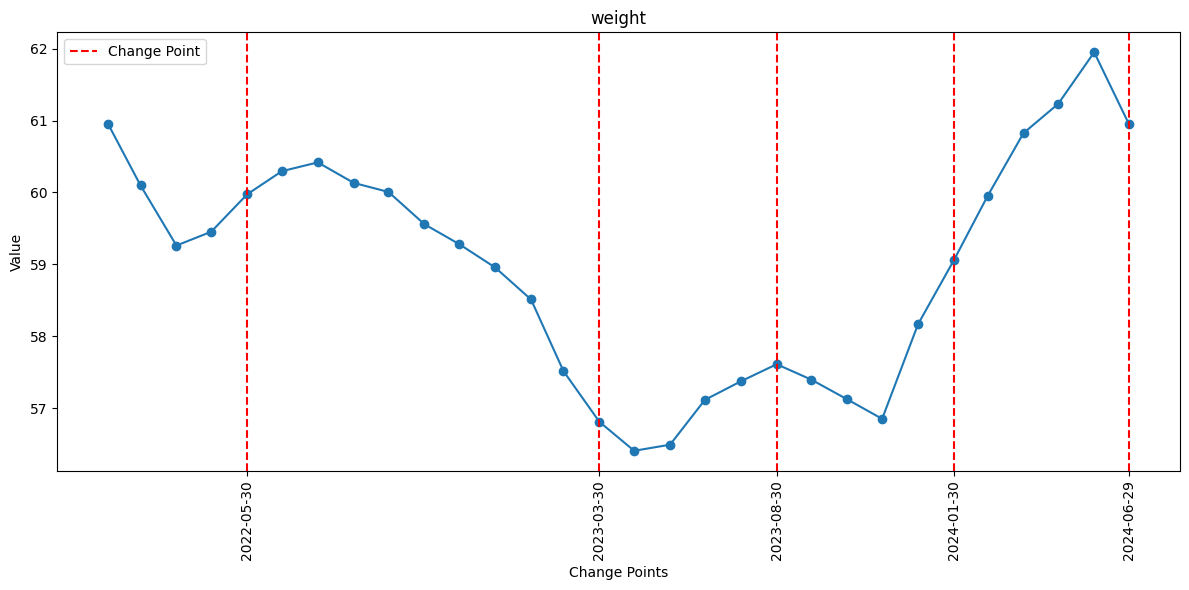

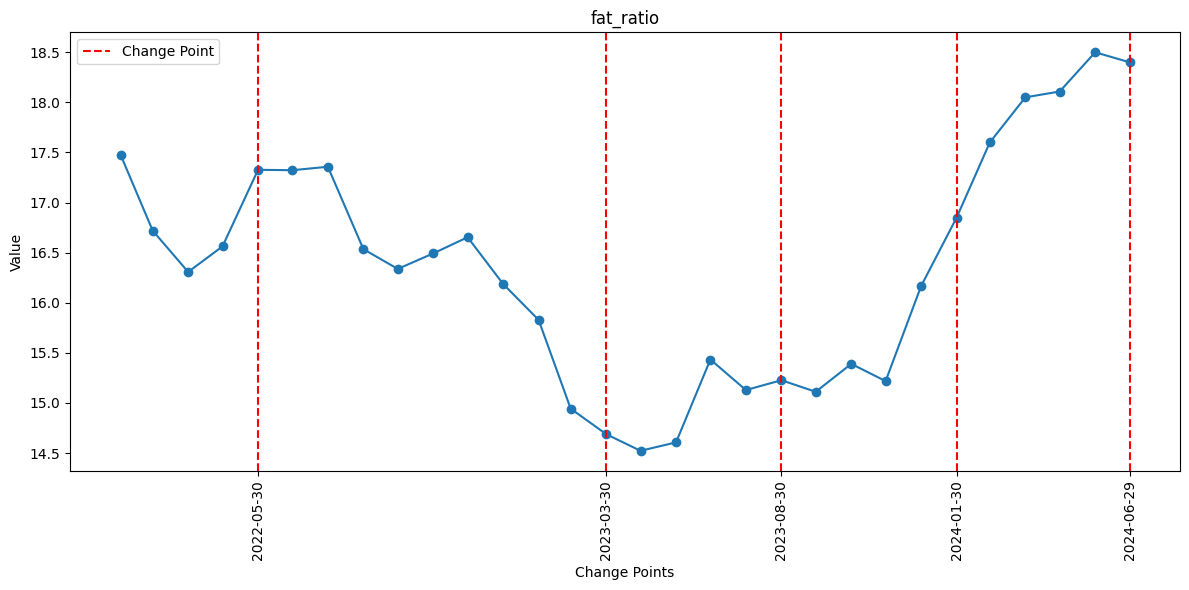

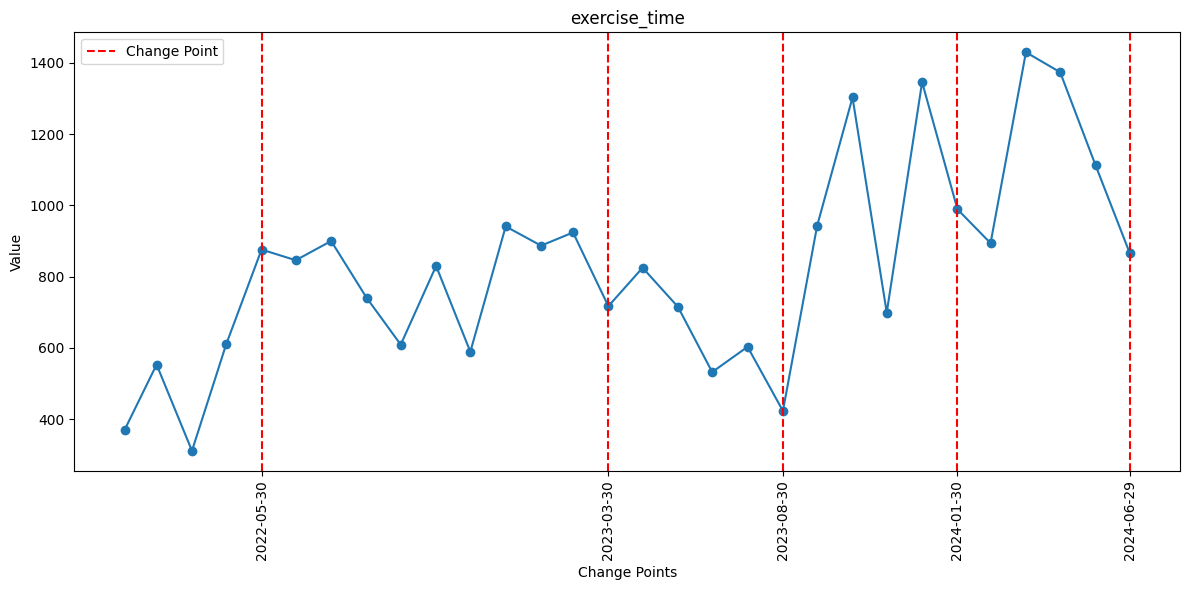

In [17]:
plot_chage_points(result, data, x_labels, target_col, marker="o")

<Axes: >

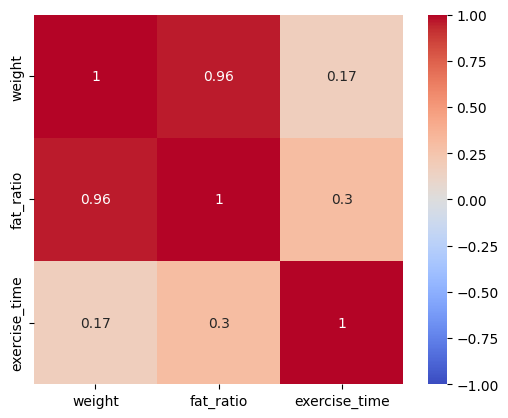

In [18]:
# 運動時間が長いと体重が減少する？ NO -> しっかり食事もしてる
sns.heatmap(merged_df[target_col].corr(), square=True, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
